In [5]:
!nvidia-smi

Sat Apr 26 10:28:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.144                Driver Version: 570.144        CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...    Off |   00000000:01:00.0  On |                  N/A |
| N/A   38C    P8              6W /   80W |     352MiB /   6141MiB |     23%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!pip install -q transformers sentencepiece gdown inference-gpu supervision more_itertools scikit-learn umap-learn
!pip install -q git+https://github.com/roboflow/sports.git

In [7]:
from inference import get_model
import os
import supervision as sv
from tqdm import tqdm
import torch
from transformers import AutoProcessor, SiglipVisionModel
from more_itertools import chunked
import numpy as np
import umap
from sklearn.cluster import KMeans

from sports.common.team import TeamClassifier

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

[04/26/25 10:28:22] WARNING  Your inference package version 0.47.0 is out of date! Please upgrade to ]8;id=180322;file:///home/dragos/coursesDeusto/DeepLearning/project2/.venv/lib/python3.12/site-packages/inference/core/__init__.py\__init__.py]8;;\:]8;id=5831;file:///home/dragos/coursesDeusto/DeepLearning/project2/.venv/lib/python3.12/site-packages/inference/core/__init__.py#41\41]8;;\
                             version 0.48.0 of inference for the latest features and bug fixes by                  
                             running `pip install --upgrade inference`.                                            

ModelDependencyMissing: Your `inference` configuration does not support Qwen2.5-VL model. Use pip install 'inference[transformers]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[clip]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration does not support GroundingDINO model. Use pip install 'inference[grounding-dino]' to install missing requirements.
ModelDependencyMissing: Your `inference` configuration d

In [8]:
api_key = os.getenv("ROBOFLOW_TOKEN")
model_id = os.getenv("PLAYER_DETECTION_MODEL_ID")
model = get_model(model_id=model_id, api_key=api_key)

2025-04-26 10:28:30.551386036 [E:onnxruntime:Default, provider_bridge_ort.cc:2036 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1695 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libnvrtc.so.12: cannot open shared object file: No such file or directory

2025-04-26 10:28:30.551404521 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:994 CreateExecutionProviderInstance] Failed to create CUDAExecutionProvider. Require cuDNN 9.* and CUDA 12.*. Please install all dependencies as mentioned in the GPU requirements page (https://onnxruntime.ai/docs/execution-providers/CUDA-ExecutionProvider.html#requirements), make sure they're in the PATH, and that your GPU is supported.


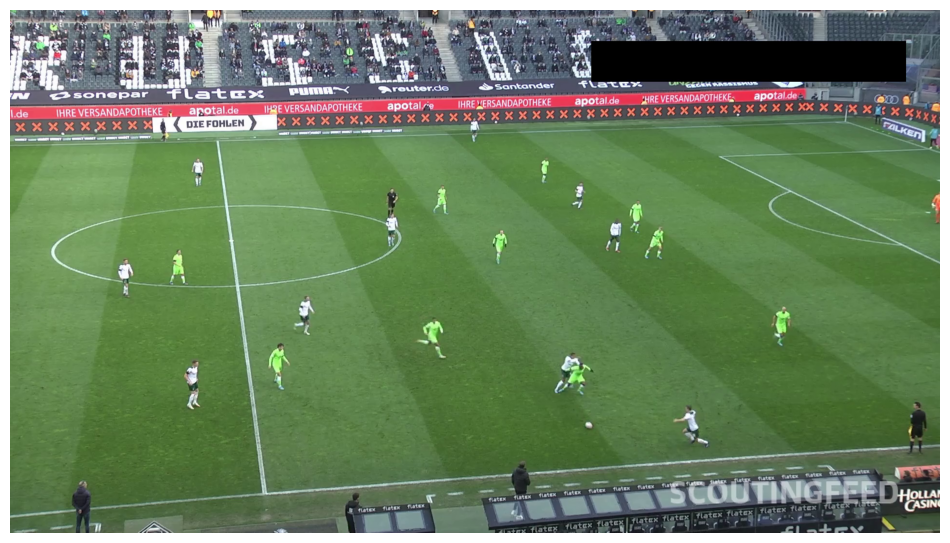

In [9]:
video_info = sv.VideoInfo.from_video_path('08fd33_4.mp4')

frame_generator = sv.get_video_frames_generator(source_path='08fd33_4.mp4')

frame = next(frame_generator)

sv.plot_image(frame)


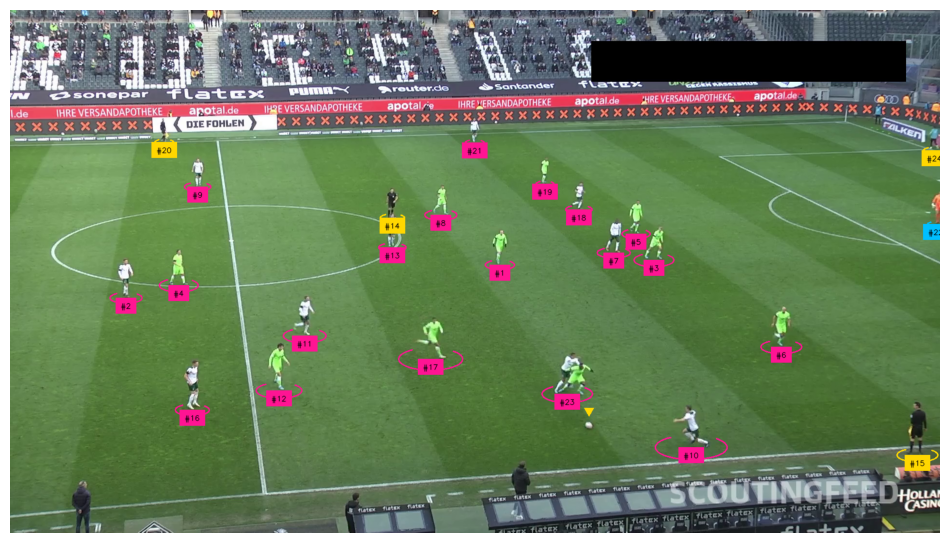

In [10]:
ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)

label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)

triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
	base=20,
	height=17
)

tracker = sv.ByteTrack()
tracker.reset()

video_info = sv.VideoInfo.from_video_path('08fd33_4.mp4')
video_sink = sv.VideoSink(
	'08fd33_4_output.mp4',
	video_info=video_info,
)

frame_generator = sv.get_video_frames_generator(source_path='08fd33_4.mp4')
frame = next(frame_generator)

result = model.infer(frame, confidence=0.3)[0]
detections = sv.Detections.from_inference(result)

ball_detections = detections[detections.class_id == 0]
ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

all_detections = detections[detections.class_id != 0]
all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True) # remove overlapping detections
all_detections.class_id = all_detections.class_id - 1
all_detections = tracker.update_with_detections(all_detections)

labels = [f"#{tracker_id}" for tracker_id in all_detections.tracker_id]

annotated_frame = frame.copy()
annotated_frame = ellipse_annotator.annotate(scene=annotated_frame, 
										detections=all_detections
										)

annotated_frame = triangle_annotator.annotate(scene=annotated_frame,
											detections=ball_detections,
											)

annotated_frame = label_annotator.annotate(scene=annotated_frame, 
                                           detections=all_detections, 
                                           labels=labels)

sv.plot_image(annotated_frame)


## Now we use this model through the sports repository on the frames

In [11]:
SOURCE_VIDEO_PATH = "08fd33_4.mp4"
PLAYER_ID = 2
STRIDE = 30

frame_generator = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO_PATH, stride=STRIDE)

crops = []
for frame in tqdm(frame_generator, desc='collecting crops'):
    result = model.infer(frame, confidence=0.3)[0]
    detections = sv.Detections.from_inference(result)
    players_detections = detections[detections.class_id == PLAYER_ID]
    players_crops = [sv.crop_image(frame, xyxy) for xyxy in detections.xyxy]
    crops += players_crops

team_classifier = TeamClassifier(device=DEVICE)
team_classifier.fit(crops)

collecting crops: 25it [01:07,  2.68s/it]
Embedding extraction: 19it [01:01,  3.25s/it]


In [12]:
def resolve_goalkeepers_team_id(players_detections: sv.Detections, goalkeepers_detections: sv.Detections):
	goalkeepers_xy = goalkeepers_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
	players_xy = players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)

	team_0_centroid = players_xy[players_detections.class_id == 0].mean(axis=0)
	team_1_centroid = players_xy[players_detections.class_id == 1].mean(axis=0)
    
	goalkeepers_team_ids = []
	for goalkeeper_xy in goalkeepers_xy:
		distance_to_team_0 = np.linalg.norm(goalkeeper_xy - team_0_centroid)
		distance_to_team_1 = np.linalg.norm(goalkeeper_xy - team_1_centroid)
		
		if distance_to_team_0 < distance_to_team_1:
			goalkeepers_team_ids.append(0)
		else:
			goalkeepers_team_ids.append(1)
		
	return np.array(goalkeepers_team_ids)
    

Embedding extraction: 1it [00:02,  2.14s/it]


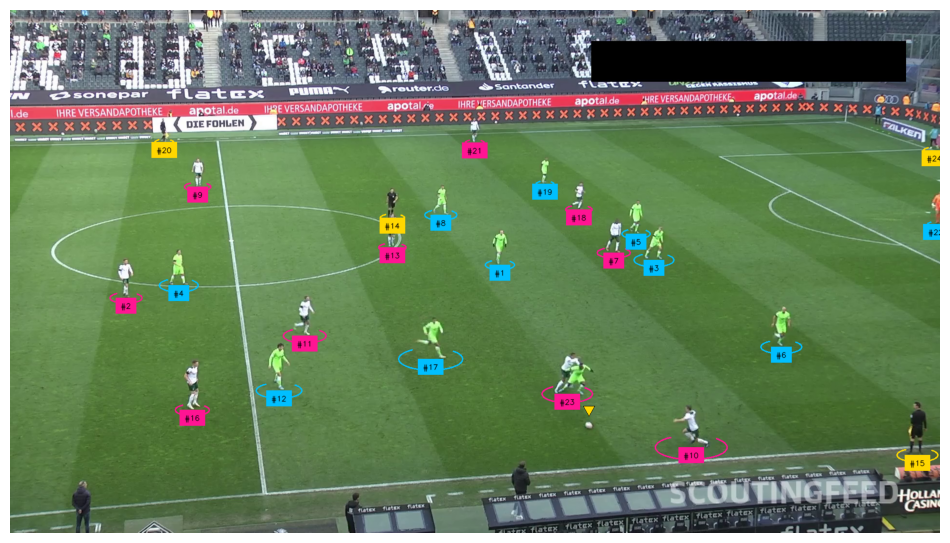

In [13]:
BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

tracker = sv.ByteTrack()
tracker.reset()

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = model.infer(frame, confidence=0.3)[0]
detections = sv.Detections.from_inference(result)

ball_detections = detections[detections.class_id == BALL_ID]
ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

all_detections = detections[detections.class_id != BALL_ID]
all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
all_detections = tracker.update_with_detections(detections=all_detections)

goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
players_detections = all_detections[all_detections.class_id == PLAYER_ID]
referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
players_detections.class_id = team_classifier.predict(players_crops)

goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
    players_detections, goalkeepers_detections)

referees_detections.class_id -= 1

all_detections = sv.Detections.merge([players_detections, goalkeepers_detections, referees_detections])

labels = [
    f"#{tracker_id}"
    for tracker_id
    in all_detections.tracker_id
]

all_detections.class_id = all_detections.class_id.astype(int)

annotated_frame = frame.copy()
annotated_frame = ellipse_annotator.annotate(
    scene=annotated_frame,
    detections=all_detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=all_detections,
    labels=labels)
annotated_frame = triangle_annotator.annotate(
    scene=annotated_frame,
    detections=ball_detections)

sv.plot_image(annotated_frame)

## Detecting pitch

In [14]:
api_key = os.getenv("ROBOFLOW_TOKEN")
field_model_id = os.getenv("FIELD_DETECTION_MODEL_ID")
pitch_model = get_model(model_id=field_model_id, api_key=api_key)

2025-04-26 10:31:07.774249016 [E:onnxruntime:Default, provider_bridge_ort.cc:2036 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1695 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libnvrtc.so.12: cannot open shared object file: No such file or directory

2025-04-26 10:31:07.774263303 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:994 CreateExecutionProviderInstance] Failed to create CUDAExecutionProvider. Require cuDNN 9.* and CUDA 12.*. Please install all dependencies as mentioned in the GPU requirements page (https://onnxruntime.ai/docs/execution-providers/CUDA-ExecutionProvider.html#requirements), make sure they're in the PATH, and that your GPU is supported.


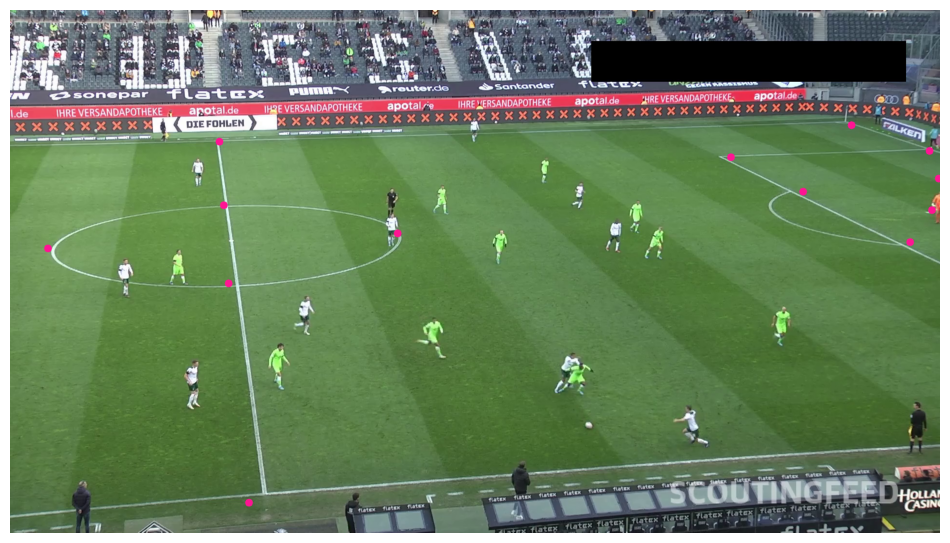

In [15]:
vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex('#FF1493'),
	radius=8
)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = pitch_model.infer(frame, confidence=0.3)[0]
key_points = sv.KeyPoints.from_inference(result)

filter = key_points.confidence[0] > 0.5
frame_reference_points = key_points.xy[0][filter]
frame_reference_key_points = sv.KeyPoints(xy=frame_reference_points[np.newaxis, ...])

annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
	scene=annotated_frame,
	key_points=frame_reference_key_points
)

sv.plot_image(annotated_frame)

In [16]:
from sports.configs.soccer import SoccerPitchConfiguration

CONFIG = SoccerPitchConfiguration()

In [23]:
#CONFIG.vertices

In [24]:
#CONFIG.edges

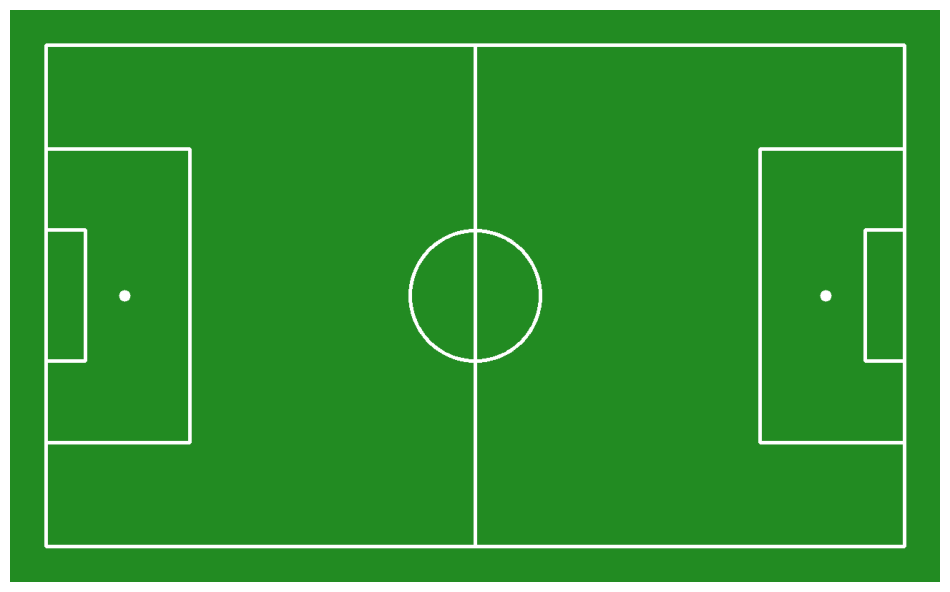

In [19]:
from sports.annotators.soccer import draw_pitch

annotated_frame = draw_pitch(CONFIG)

sv.plot_image(annotated_frame)

In [21]:
import cv2

class ViewTransformer:
	def __init__(self, source: np.ndarray, target: np.ndarray):
		source = source.astype(np.float32)
		target = target.astype(np.float32)
		self.m, _ = cv2.findHomography(source, target)
		
	def transform_points(self, points: np.ndarray):
		points = points.reshape(-1, 1, 2).astype(np.float32)
		points = cv2.perspectiveTransform(points, self.m)
		return points.reshape(-1, 2).astype(np.float32)

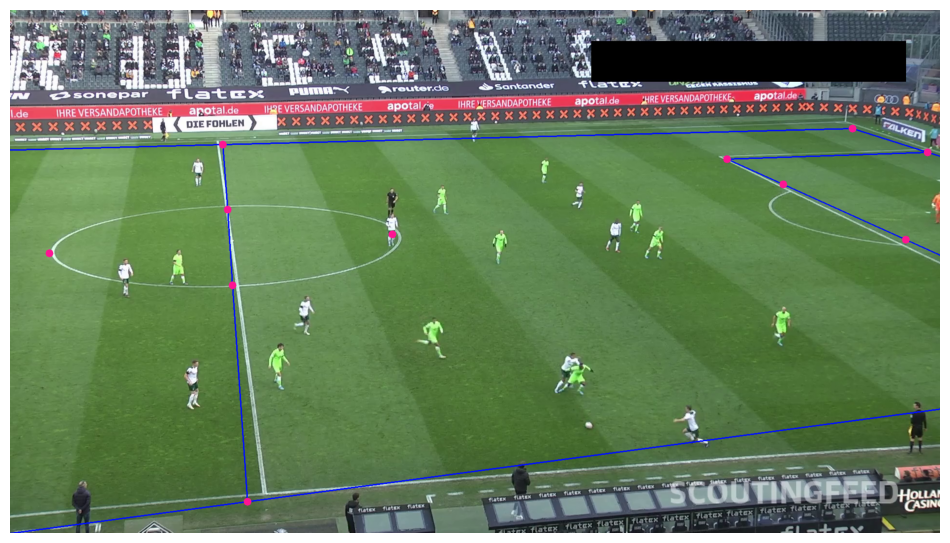

In [ ]:
vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex('#FF1493'),
	radius=8
)

edge_annotator = sv.EdgeAnnotator(
	color=sv.Color.from_hex('#000FFF'),
	thickness=2,
    edges=CONFIG.edges
)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = pitch_model.infer(frame, confidence=0.3)[0]
key_points = sv.KeyPoints.from_inference(result)

filter = key_points.confidence[0] > 0.5
frame_reference_points = key_points.xy[0][filter]
frame_reference_key_points = sv.KeyPoints(xy=frame_reference_points[np.newaxis, ...])
pitch_reference_points = np.array(CONFIG.vertices)[filter]

view_transformer = ViewTransformer(
    source=pitch_reference_points,
    target=frame_reference_points
)

pitch_all_Points = np.array(CONFIG.vertices)
frame_all_points = view_transformer.transform_points(pitch_all_Points)
frame_all_key_points = sv.KeyPoints(xy=frame_all_points[np.newaxis, ...])

annotated_frame = frame.copy()
annotated_frame = edge_annotator.annotate(
	scene=annotated_frame,
	key_points=frame_all_key_points
)
annotated_frame = vertex_annotator.annotate(
	scene=annotated_frame,
	key_points=frame_all_key_points
)

sv.plot_image(annotated_frame)

Embedding extraction: 1it [00:03,  3.37s/it]


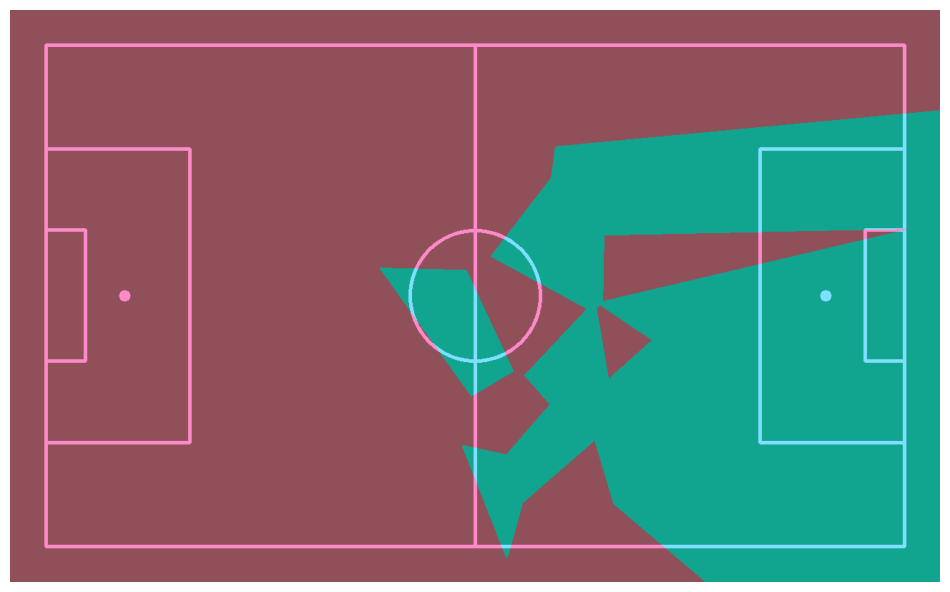

In [29]:
from sports.annotators.soccer import draw_pitch, draw_points_on_pitch, draw_pitch_voronoi_diagram

BALL_ID = 0
GOALKEEPER_ID = 1
PLAYER_ID = 2
REFEREE_ID = 3



tracker = sv.ByteTrack()
tracker.reset()

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = model.infer(frame, confidence=0.3)[0]
detections = sv.Detections.from_inference(result)

ball_detections = detections[detections.class_id == BALL_ID]
ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

all_detections = detections[detections.class_id != BALL_ID]
all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
all_detections = tracker.update_with_detections(detections=all_detections)

goalkeepers_detections = all_detections[all_detections.class_id == GOALKEEPER_ID]
players_detections = all_detections[all_detections.class_id == PLAYER_ID]
referees_detections = all_detections[all_detections.class_id == REFEREE_ID]

players_crops = [sv.crop_image(frame, xyxy) for xyxy in players_detections.xyxy]
players_detections.class_id = team_classifier.predict(players_crops)

goalkeepers_detections.class_id = resolve_goalkeepers_team_id(
    players_detections, goalkeepers_detections)



result = pitch_model.infer(frame, confidence=0.3)[0]
key_points = sv.KeyPoints.from_inference(result)

filter = key_points.confidence[0] > 0.5
frame_reference_points = key_points.xy[0][filter]
frame_reference_key_points = sv.KeyPoints(xy=frame_reference_points[np.newaxis, ...])
pitch_reference_points = np.array(CONFIG.vertices)[filter]

view_transformer = ViewTransformer(
    source=frame_reference_points,
    target=pitch_reference_points
)

frame_ball_xy = ball_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_ball_xy = view_transformer.transform_points(frame_ball_xy)

frame_players_xy = players_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_players_xy = view_transformer.transform_points(frame_players_xy)

frame_referees_xy = referees_detections.get_anchors_coordinates(sv.Position.BOTTOM_CENTER)
pitch_referees_xy = view_transformer.transform_points(frame_referees_xy)

pitch = draw_pitch(config=CONFIG)
pitch = draw_pitch_voronoi_diagram(
    config=CONFIG,
    team_1_xy=pitch_players_xy[players_detections.class_id == 0],
    team_2_xy=pitch_players_xy[players_detections.class_id == 1],
    team_1_color=sv.Color.from_hex('00BFFF'),
    team_2_color=sv.Color.from_hex('FF1493'),
    pitch=pitch
)

sv.plot_image(pitch)

In [ ]:
pitch = draw_points_on_pitch(
    config=CONFIG,
    xy=pitch_ball_xy,
    face_color=sv.Color.WHITE,
    edge_color=sv.Color.BLACK,
    radius=10,
    pitch=pitch
)
pitch = draw_points_on_pitch(
    config=CONFIG,
    xy=pitch_players_xy[players_detections.class_id == 0],
    face_color=sv.Color.from_hex('00BFFF'),
    edge_color=sv.Color.BLACK,
    radius=10,
    pitch=pitch
)
pitch = draw_points_on_pitch(
    config=CONFIG,
    xy=pitch_players_xy[players_detections.class_id == 1],
    face_color=sv.Color.from_hex("FF1493"),
    edge_color=sv.Color.BLACK,
    radius=10,
    pitch=pitch
)
pitch = draw_points_on_pitch(
    config=CONFIG,
    xy=pitch_referees_xy,
    face_color=sv.Color.from_hex("FFD700"),
    edge_color=sv.Color.BLACK,
    radius=10,
    pitch=pitch
)

Ball tracking is not solved yet.

Quantization